In [1]:
import os
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold,
    KFold
)
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder,
    FunctionTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
import xgboost as xgb
warnings.filterwarnings('ignore')

In [2]:
if os.path.exists('price_dataset.csv'):
    df = pd.read_csv('price_dataset.csv')
    print('Dataset imported successfully')
else:
    print('Dataset not found')

Dataset imported successfully


#### Exploratory Data Analysis

In [3]:
df.head()

,commodity_name,state,district,market,min_price,max_price,modal_price,date
0,Ajwan,Gujarat,Amreli,Amreli,63.25,79.55,79.55,2019-05-22
1,Ajwan,Gujarat,Banaskanth,Dhanera,80.05,80.05,80.05,2019-05-22
2,Ajwan,Gujarat,Jamnagar,Jamnagar,90.00,155.00,122.50,2019-05-22
3,Ajwan,Gujarat,Mehsana,Kadi,94.50,112.50,107.00,2019-05-22
4,Ajwan,Gujarat,Mehsana,Unjha,21.25,148.50,99.75,2019-05-22


In [4]:
df.shape

(836977, 8)

This dataset consists of **836977 rows** in total.

Each row has **8** columns representing **commodity_name, state, district, market, min_price, max_price, modal_price and date**

In [5]:
cols = df.columns

print('Columns: \n')

for col in cols:
    print(col)

Columns: 

commodity_name
state
district
market
min_price
max_price
modal_price
date


In [6]:
# CLEAN DATA
df = df.dropna(subset=['modal_price'])

# Convert date safely
df['date'] = pd.to_datetime(
    df['date'],
    errors='coerce'
)

df = df.dropna(subset=['date'])

In [7]:
commoditys = df['commodity_name'].unique()

print('commodity_names: \n')

for commodity in commoditys:
    print(commodity)

commodity_names: 

Ajwan
Alasande+Gram
Amaranthus
Amla(Nelli+Kai)
Amphophalus
Antawala
Apple
Arhar+Dal(Tur+Dal)
Ashgourd
Avare+Dal
Banana
Banana+-+Green
Barley+(Jau)
Beans
Beaten+Rice
Beetroot
Betal+Leaves
Bitter+gourd
Black+pepper
Bottle+gourd
Brinjal
Broken+Rice
Cabbage
Capsicum
Cardamoms
Carrot
Cashewnuts
Castor+Seed
Cauliflower
Coconut
Chapparad+Avare
Chennangi+Dal
Chikoos(Sapota)
Chili+Red
Chilly+Capsicum
Cloves
Cluster+beans
Cocoa
Coconut+Oil
Coconut+Seed
Coffee
Colacasia
Copra
Coriander(Leaves)
Corriander+seed
Cowpea(Veg)
Cotton
Cucumbar(Kheera)
Cummin+Seed(Jeera)
Drumstick
Dry+Chillies
Dry+Fodder
Dry+Grapes
Duster+Beans
Egg
Elephant+Yam+(Suran)
Field+Pea
Firewood
Fish
Garlic
Ghee
Gingelly+Oil
Ginger(Dry)
Ginger(Green)
Grapes
Green+Avare+(W)
Green+Chilli
Green+Fodder
Green+Peas
Ground+Nut+Seed
Groundnut
Groundnut+(Split)
Groundnut+pods+(raw)
Guar
Guava
Gur(Jaggery)
Hen
Hybrid+Cumbu
Indian+Beans+(Seam)
Isabgul+(Psyllium)
Jack+Fruit
Jamun(Narale+Hannu)
Jowar(Sorghum)
Jute
Karbuja(

In [8]:
df.dtypes

commodity_name               str
state                        str
district                     str
market                       str
min_price                float64
max_price                float64
modal_price              float64
date              datetime64[us]
dtype: object

In [9]:
# FEATURE ENGINEERING

# Month
df['month'] = df['date'].dt.month

# Season
df['season'] = (
    (df['month'] % 12 + 3) // 3
)

# Price target
df['modal_price'] = (
    df['modal_price'] * 100
)

# FEATURES & TARGET

features = [
    'commodity_name',
    'state',
    'district',
    'market',
    'month',
    'season'
]

target = 'modal_price'

X = df[features].copy()
y = df[target]

In [10]:
# ENCODE CATEGORICAL FEATURES

encoders = {}

categorical_cols = [
    'commodity_name',
    'state',
    'district',
    'market'
]

for col in categorical_cols:

    X[col] = (
        X[col]
        .astype(str)
        .fillna('Unknown')
    )

    le = LabelEncoder()

    le.fit(
        list(X[col].unique()) +
        ['Unknown']
    )

    X[col] = le.transform(X[col])

    encoders[col] = le

# Save encoders in current directory

with open("price_encoders.pkl", 'wb') as f:
    pickle.dump(encoders, f)

print("Encoders saved successfully!")

Encoders saved successfully!


In [11]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# MODELS

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=15,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1
    )
}

In [16]:
# CROSS VALIDATION

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# STORE RESULTS

results = []
best_model = None
best_r2 = -999
best_model_name = ""

# TRAIN & EVALUATE

for model_name, model in models.items():

    print(f"\nTraining {model_name}...")
    
    # TRAIN
    model.fit(X_train, y_train)

    # PREDICT
    y_pred = model.predict(X_test)

    # METRICS
    r2 = r2_score(
        y_test,
        y_pred
    )

    # Convert R2 into percentage style
    accuracy_percent = r2 * 100

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    # CROSS VALIDATION
    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )

    cv_mean = cv_scores.mean()

    cv_std = cv_scores.std()

    # STORE RESULTS
    results.append([
        model_name,
        accuracy_percent,
        r2,
        mae,
        rmse,
        cv_mean,
        cv_std
    ])

    # BEST MODEL TRACKING
    if cv_mean > best_r2:
        best_r2 = cv_mean
        best_model = model
        best_model_name = model_name

    # PRINT RESULTS

    print(f"Accuracy: {accuracy_percent:.2f}%")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"CV R2 Mean: {cv_mean:.4f}")


Training Linear Regression...
Accuracy: 0.82%
R2 Score: 0.0082
MAE: 1942.66
RMSE: 7544.56
CV R2 Mean: 0.0180

Training Ridge Regression...
Accuracy: 0.82%
R2 Score: 0.0082
MAE: 1942.66
RMSE: 7544.56
CV R2 Mean: 0.0180

Training Lasso Regression...
Accuracy: 0.82%
R2 Score: 0.0082
MAE: 1942.66
RMSE: 7544.56
CV R2 Mean: 0.0180

Training Decision Tree...
Accuracy: 92.26%
R2 Score: 0.9226
MAE: 631.48
RMSE: 2108.28
CV R2 Mean: 0.7477

Training Random Forest...
Accuracy: 87.64%
R2 Score: 0.8764
MAE: 475.42
RMSE: 2663.82
CV R2 Mean: 0.7826

Training XGBoost...
Accuracy: 73.36%
R2 Score: 0.7336
MAE: 799.50
RMSE: 3909.74
CV R2 Mean: 0.6323


In [17]:
# RESULTS DATAFRAME

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy (%)',
        'R2 Score',
        'MAE',
        'RMSE',
        'CV R2 Mean',
        'CV Std'    
    ]
)

# Sort by CV score
results_df = results_df.sort_values(
    by='CV R2 Mean',
    ascending=False
)

print("\nFINAL MODEL COMPARISON:\n")
print(results_df)


FINAL MODEL COMPARISON:

               Model  Accuracy (%)  R2 Score          MAE         RMSE  \
4      Random Forest     87.635764  0.876358   475.419897  2663.822084   
3      Decision Tree     92.255147  0.922551   631.484103  2108.279281   
5            XGBoost     73.364998  0.733650   799.499536  3909.740483   
2   Lasso Regression      0.819881  0.008199  1942.658149  7544.559304   
1   Ridge Regression      0.819892  0.008199  1942.656307  7544.558912   
0  Linear Regression      0.819892  0.008199  1942.656306  7544.558912   

   CV R2 Mean    CV Std  
4    0.782585  0.142469  
3    0.747726  0.189398  
5    0.632343  0.126779  
2    0.018030  0.008864  
1    0.018030  0.008864  
0    0.018030  0.008864  


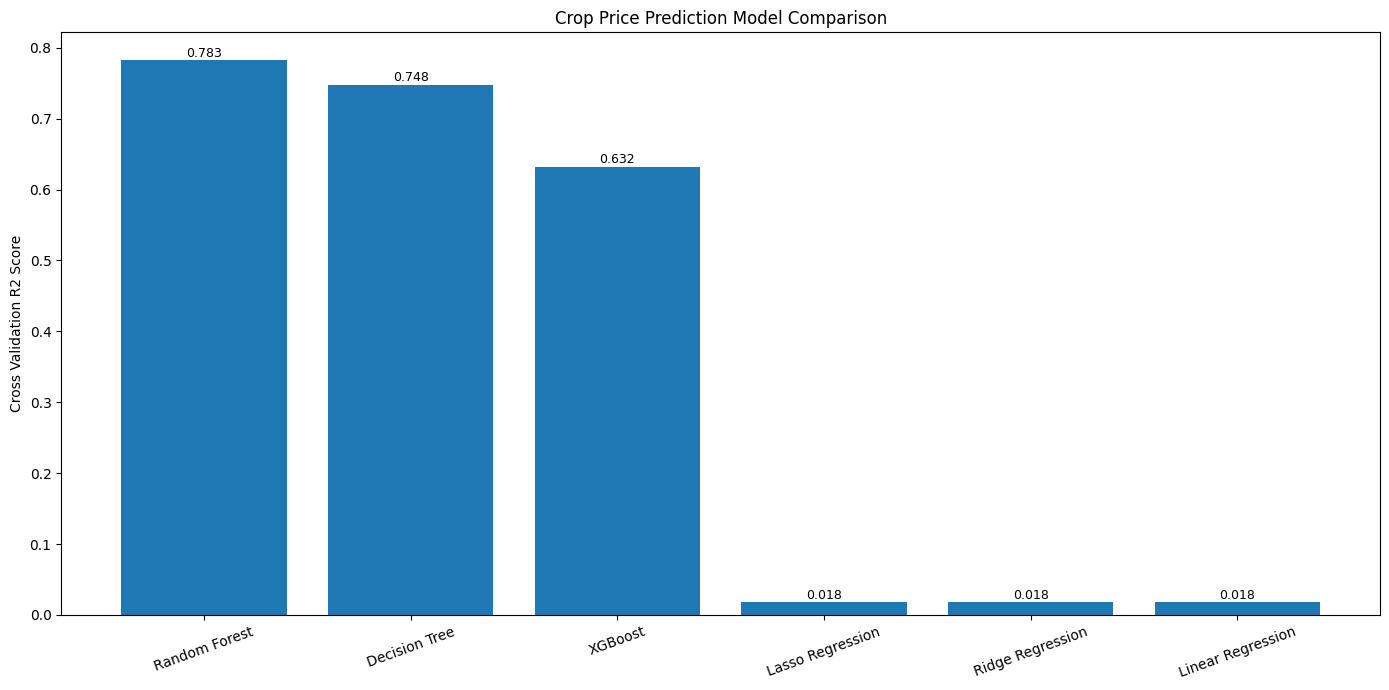

In [21]:
# VISUALIZATION

plt.figure(figsize=(14, 7))

bars = plt.bar(
    results_df['Model'],
    results_df['CV R2 Mean']
)

plt.xticks(rotation=20)
plt.ylabel("Cross Validation R2 Score")
plt.title("Crop Price Prediction Model Comparison")

# Add values
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [20]:
# SAVE BEST MODEL

model_path = os.path.join(
    "price_model.pkl"
)

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"\nBest Model: {best_model_name}")
print(f"Best CV R2 Score: {best_r2:.4f}")
print(f"Model saved successfully to: {model_path}")
print("\nTraining Complete.")


Best Model: Random Forest
Best CV R2 Score: 0.7826
Model saved successfully to: price_model.pkl

Training Complete.
